## Notebook 04 — Granger Causality Tests

This notebook runs formal Granger causality F-tests across all hypothesised commodity → equity pairs, across all momentum lookback windows and lag orders.

**The test:** For commodity series $X$ and equity series $Y$, we ask whether lagged values of $X$ improve the forecast of $Y$ beyond $Y$'s own history.

Unrestricted model:
$$Y_t = \alpha + \sum_{k=1}^{p} \beta_k Y_{t-k} + \sum_{k=1}^{p} \gamma_k X_{t-k} + \varepsilon_t$$

We reject H₀ ($\gamma_k = 0$ for all $k$) when the F-statistic p-value < 0.05.

**Sections:**
1. Load data
2. Granger test — all pairs × windows × lags
3. Results table
4. Heatmap visualisation
5. Optimal lag analysis
6. Reverse causality check
7. Save results

---
### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
import os
warnings.filterwarnings('ignore')

PROC_DIR = os.path.join("..", "data", "processed")
OUT_DIR  = os.path.join("..", "outputs")
FIG_DIR  = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

COMMODITIES = ["WTI", "Brent", "Copper", "NatGas", "Gold"]
EQUITIES    = ["XLE", "XLB", "GDX"]
ALL_ASSETS  = COMMODITIES + EQUITIES

PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

WINDOWS   = [5, 10, 20]
MAX_LAG   = 5
SIG_LEVEL = 0.05

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

# Load momentum signals
momentum = {}
for w in WINDOWS:
    momentum[w] = pd.read_csv(
        os.path.join(PROC_DIR, f"momentum_w{w}.csv"),
        index_col=0, parse_dates=True
    )

print("Momentum signals loaded:")
for w in WINDOWS:
    print(f"  w={w} | shape={momentum[w].shape}")

Momentum signals loaded:
  w=5 | shape=(4122, 8)
  w=10 | shape=(4122, 8)
  w=20 | shape=(4122, 8)


---
### 2. Granger Causality Tests

We test every combination of: pair × window × lag order.

For each test we record the F-statistic and p-value. We use the F-test (more reliable than chi-squared for finite samples).

In [2]:
def run_granger(x_series, y_series, max_lag):
    """
    Run Granger causality test: does X Granger-cause Y?
    Returns a dict of {lag: {f_stat, p_value}} for lags 1..max_lag.
    """
    data = pd.DataFrame({"Y": y_series, "X": x_series}).dropna()
    results = grangercausalitytests(data[["Y", "X"]], maxlag=max_lag, verbose=False)
    output = {}
    for lag in range(1, max_lag + 1):
        f_stat = results[lag][0]["ssr_ftest"][0]
        p_val  = results[lag][0]["ssr_ftest"][1]
        output[lag] = {"f_stat": round(f_stat, 4), "p_value": round(p_val, 4)}
    return output


# Run all tests
records = []

for comm, eq in PAIRS:
    for w in WINDOWS:
        x = momentum[w][comm]
        y = momentum[w][eq]
        granger_results = run_granger(x, y, MAX_LAG)

        for lag, vals in granger_results.items():
            records.append({
                "Commodity" : comm,
                "Equity"    : eq,
                "Pair"      : f"{comm}→{eq}",
                "Window"    : w,
                "Lag"       : lag,
                "F_stat"    : vals["f_stat"],
                "P_value"   : vals["p_value"],
                "Significant": vals["p_value"] < SIG_LEVEL
            })

results_df = pd.DataFrame(records)
print(f"Total tests run : {len(results_df)}")
print(f"Significant     : {results_df['Significant'].sum()} ({results_df['Significant'].mean():.1%})")

Total tests run : 75
Significant     : 32 (42.7%)


---
### 3. Results Table

In [3]:
# Full results
pd.set_option('display.max_rows', 100)
print(results_df.to_string(index=False))

Commodity Equity       Pair  Window  Lag  F_stat  P_value  Significant
      WTI    XLE    WTI→XLE       5    1  1.1823   0.2770        False
      WTI    XLE    WTI→XLE       5    2  0.8870   0.4120        False
      WTI    XLE    WTI→XLE       5    3  1.2314   0.2966        False
      WTI    XLE    WTI→XLE       5    4  5.1213   0.0004         True
      WTI    XLE    WTI→XLE       5    5  4.4787   0.0005         True
      WTI    XLE    WTI→XLE      10    1  7.0203   0.0081         True
      WTI    XLE    WTI→XLE      10    2  3.2153   0.0402         True
      WTI    XLE    WTI→XLE      10    3  3.3218   0.0190         True
      WTI    XLE    WTI→XLE      10    4  4.3783   0.0016         True
      WTI    XLE    WTI→XLE      10    5  3.0495   0.0094         True
      WTI    XLE    WTI→XLE      20    1  3.2448   0.0717        False
      WTI    XLE    WTI→XLE      20    2  4.8942   0.0075         True
      WTI    XLE    WTI→XLE      20    3  6.1883   0.0003         True
      

In [4]:
# Summary: for each pair × window, which lags are significant?
print("SIGNIFICANT GRANGER RESULTS (p < 0.05)")
print("=" * 65)
sig = results_df[results_df["Significant"]]

for (comm, eq, w), group in sig.groupby(["Commodity", "Equity", "Window"]):
    lags = list(group["Lag"])
    best = group.loc[group["F_stat"].idxmax()]
    print(f"{comm}→{eq} | w={w:>2} | sig lags={lags} | best lag={int(best['Lag'])} F={best['F_stat']:.2f} p={best['P_value']:.4f}")

SIGNIFICANT GRANGER RESULTS (p < 0.05)
Brent→XLE | w= 5 | sig lags=[1, 3, 4, 5] | best lag=4 F=5.50 p=0.0002
Brent→XLE | w=10 | sig lags=[4] | best lag=4 F=2.72 p=0.0281
Brent→XLE | w=20 | sig lags=[4, 5] | best lag=4 F=5.89 p=0.0001
Copper→XLB | w=10 | sig lags=[5] | best lag=5 F=2.87 p=0.0138
Copper→XLB | w=20 | sig lags=[5] | best lag=5 F=2.93 p=0.0121
Gold→GDX | w= 5 | sig lags=[3, 4, 5] | best lag=3 F=18.90 p=0.0000
Gold→GDX | w=10 | sig lags=[1, 2, 3, 4, 5] | best lag=1 F=14.04 p=0.0002
Gold→GDX | w=20 | sig lags=[1, 3, 4] | best lag=3 F=4.96 p=0.0019
NatGas→XLE | w=20 | sig lags=[4] | best lag=4 F=2.43 p=0.0457
WTI→XLE | w= 5 | sig lags=[4, 5] | best lag=4 F=5.12 p=0.0004
WTI→XLE | w=10 | sig lags=[1, 2, 3, 4, 5] | best lag=1 F=7.02 p=0.0081
WTI→XLE | w=20 | sig lags=[2, 3, 4, 5] | best lag=4 F=8.78 p=0.0000


---
### 4. Heatmap — F-statistics Across Pairs and Lags

One heatmap per momentum window. Rows = pairs, columns = lag orders. Cell colour = F-statistic magnitude. Cells with p ≥ 0.05 are marked with ✗.

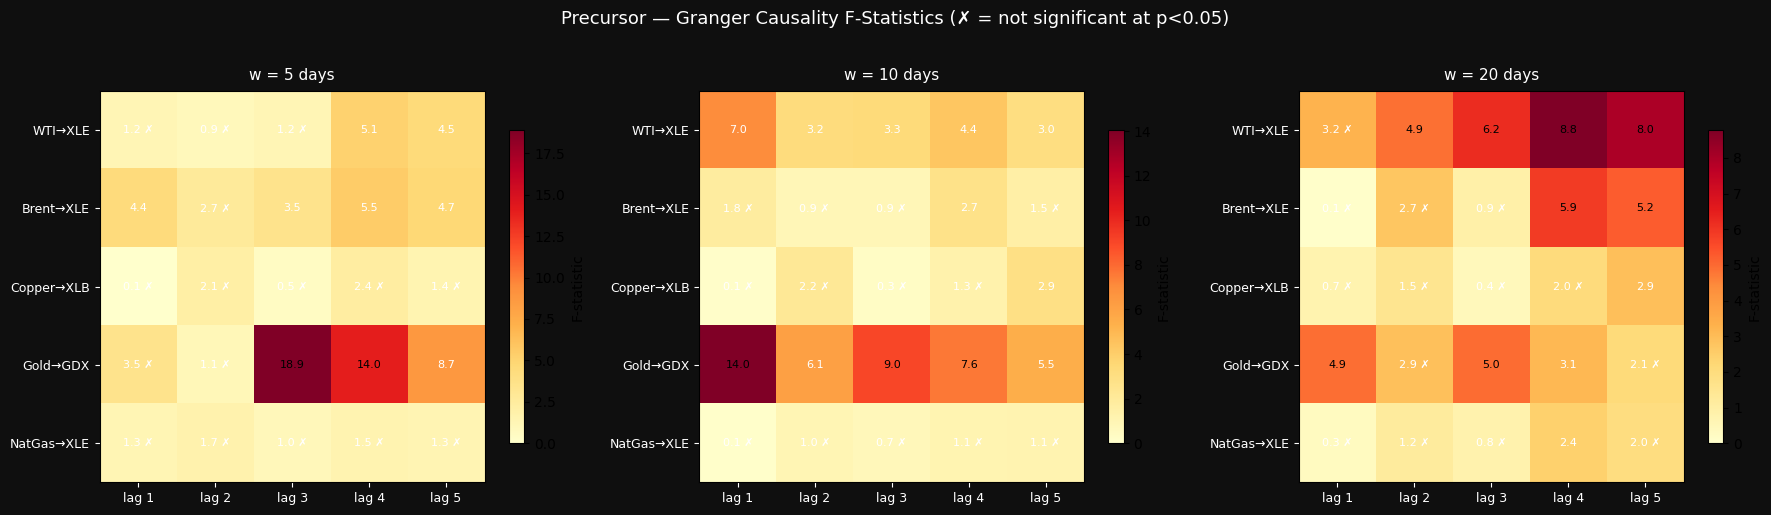

Saved: figures/04_granger_heatmap.png


In [5]:
pair_labels = [f"{c}→{e}" for c, e in PAIRS]
lag_labels  = [str(l) for l in range(1, MAX_LAG + 1)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0f0f0f")

for col, w in enumerate(WINDOWS):
    ax = axes[col]
    ax.set_facecolor("#1a1a1a")

    subset = results_df[results_df["Window"] == w]

    # Build F-stat matrix
    f_matrix = np.zeros((len(PAIRS), MAX_LAG))
    p_matrix = np.ones((len(PAIRS), MAX_LAG))

    for i, (comm, eq) in enumerate(PAIRS):
        for j, lag in enumerate(range(1, MAX_LAG + 1)):
            row = subset[(subset["Commodity"] == comm) &
                         (subset["Equity"] == eq) &
                         (subset["Lag"] == lag)]
            if not row.empty:
                f_matrix[i, j] = row["F_stat"].values[0]
                p_matrix[i, j] = row["P_value"].values[0]

    im = ax.imshow(f_matrix, cmap="YlOrRd", aspect="auto", vmin=0)

    # Annotate cells
    for i in range(len(PAIRS)):
        for j in range(MAX_LAG):
            sig_marker = "" if p_matrix[i, j] < SIG_LEVEL else " ✗"
            ax.text(j, i, f"{f_matrix[i,j]:.1f}{sig_marker}",
                    ha="center", va="center", fontsize=8,
                    color="black" if f_matrix[i, j] > f_matrix.max() * 0.5 else "white")

    ax.set_xticks(range(MAX_LAG))
    ax.set_xticklabels([f"lag {l}" for l in range(1, MAX_LAG + 1)], color="white", fontsize=9)
    ax.set_yticks(range(len(PAIRS)))
    ax.set_yticklabels(pair_labels, color="white", fontsize=9)
    ax.set_title(f"w = {w} days", color="white", fontsize=11, pad=8)
    ax.tick_params(colors="white")

    plt.colorbar(im, ax=ax, shrink=0.8, label="F-statistic")

fig.suptitle("Precursor — Granger Causality F-Statistics (✗ = not significant at p<0.05)",
             color="white", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_granger_heatmap.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/04_granger_heatmap.png")

---
### 5. Optimal Lag Per Pair

For each pair, identify the lag order that produces the strongest Granger signal (highest F-stat among significant results). This lag becomes $k^*$ used in the backtest.

In [6]:
print("OPTIMAL LAG PER PAIR (highest F-stat among significant tests)")
print("=" * 70)

optimal = []

for comm, eq in PAIRS:
    pair_sig = results_df[
        (results_df["Commodity"] == comm) &
        (results_df["Equity"] == eq) &
        (results_df["Significant"])
    ]

    if pair_sig.empty:
        print(f"{comm}→{eq} : NO significant results")
        optimal.append({"Pair": f"{comm}→{eq}", "Commodity": comm, "Equity": eq,
                        "Optimal_Lag": None, "Optimal_Window": None,
                        "Best_F": None, "Best_P": None})
    else:
        best = pair_sig.loc[pair_sig["F_stat"].idxmax()]
        print(f"{comm}→{eq} : optimal lag={int(best['Lag'])} window={int(best['Window'])} "
              f"F={best['F_stat']:.2f} p={best['P_value']:.4f}")
        optimal.append({
            "Pair"          : f"{comm}→{eq}",
            "Commodity"     : comm,
            "Equity"        : eq,
            "Optimal_Lag"   : int(best["Lag"]),
            "Optimal_Window": int(best["Window"]),
            "Best_F"        : best["F_stat"],
            "Best_P"        : best["P_value"]
        })

optimal_df = pd.DataFrame(optimal)
print("\n", optimal_df.to_string(index=False))

OPTIMAL LAG PER PAIR (highest F-stat among significant tests)
WTI→XLE : optimal lag=4 window=20 F=8.78 p=0.0000
Brent→XLE : optimal lag=4 window=20 F=5.89 p=0.0001
Copper→XLB : optimal lag=5 window=20 F=2.93 p=0.0121
Gold→GDX : optimal lag=3 window=5 F=18.90 p=0.0000
NatGas→XLE : optimal lag=4 window=20 F=2.43 p=0.0457

       Pair Commodity Equity  Optimal_Lag  Optimal_Window  Best_F  Best_P
   WTI→XLE       WTI    XLE            4              20  8.7785  0.0000
 Brent→XLE     Brent    XLE            4              20  5.8891  0.0001
Copper→XLB    Copper    XLB            5              20  2.9297  0.0121
  Gold→GDX      Gold    GDX            3               5 18.8961  0.0000
NatGas→XLE    NatGas    XLE            4              20  2.4287  0.0457


---
### 6. Reverse Causality Check

A critical robustness check. If equity momentum also Granger-causes commodity momentum, the relationship is bidirectional and the spillover interpretation weakens. We test equity → commodity for all pairs.

In [7]:
print("REVERSE CAUSALITY CHECK: Equity → Commodity")
print("Does equity momentum predict commodity momentum? (Should be weaker)")
print("=" * 70)

reverse_records = []

for comm, eq in PAIRS:
    for w in WINDOWS:
        # Reversed: Y=commodity, X=equity
        x = momentum[w][eq]
        y = momentum[w][comm]
        rev_results = run_granger(x, y, MAX_LAG)

        for lag, vals in rev_results.items():
            reverse_records.append({
                "Pair"       : f"{eq}→{comm}",
                "Window"     : w,
                "Lag"        : lag,
                "F_stat"     : vals["f_stat"],
                "P_value"    : vals["p_value"],
                "Significant": vals["p_value"] < SIG_LEVEL
            })

reverse_df = pd.DataFrame(reverse_records)
sig_reverse = reverse_df[reverse_df["Significant"]]

print(f"\nForward  (commodity→equity) significant tests : {results_df['Significant'].sum()}")
print(f"Reverse  (equity→commodity) significant tests : {sig_reverse.shape[0]}")
print(f"\nReverse significant results:")
if sig_reverse.empty:
    print("None — clean unidirectional causality.")
else:
    for (pair, w), group in sig_reverse.groupby(["Pair", "Window"]):
        lags = list(group["Lag"])
        best = group.loc[group["F_stat"].idxmax()]
        print(f"{pair} | w={w} | sig lags={lags} | best F={best['F_stat']:.2f} p={best['P_value']:.4f}")

REVERSE CAUSALITY CHECK: Equity → Commodity
Does equity momentum predict commodity momentum? (Should be weaker)

Forward  (commodity→equity) significant tests : 32
Reverse  (equity→commodity) significant tests : 59

Reverse significant results:
GDX→Gold | w=5 | sig lags=[1, 2, 3, 4, 5] | best F=139.17 p=0.0000
GDX→Gold | w=10 | sig lags=[1, 2, 3, 4, 5] | best F=132.09 p=0.0000
GDX→Gold | w=20 | sig lags=[1, 2, 3, 4, 5] | best F=76.29 p=0.0000
XLB→Copper | w=5 | sig lags=[1, 2, 3, 4, 5] | best F=25.05 p=0.0000
XLB→Copper | w=10 | sig lags=[1, 2, 3, 4, 5] | best F=32.15 p=0.0000
XLB→Copper | w=20 | sig lags=[1, 2, 3, 4, 5] | best F=24.84 p=0.0000
XLE→Brent | w=5 | sig lags=[1, 2, 3, 4, 5] | best F=9.32 p=0.0000
XLE→Brent | w=10 | sig lags=[1, 2, 3, 4, 5] | best F=39.39 p=0.0000
XLE→Brent | w=20 | sig lags=[1, 2, 3, 4, 5] | best F=27.03 p=0.0000
XLE→WTI | w=5 | sig lags=[2, 3, 4, 5] | best F=6.02 p=0.0001
XLE→WTI | w=10 | sig lags=[1, 2, 3, 4, 5] | best F=40.08 p=0.0000
XLE→WTI | w=20 | s

---
### 7. F-stat Comparison: Forward vs Reverse

In [8]:
# For each pair at w=10, lag=1: compare forward vs reverse F-stat
print("FORWARD vs REVERSE F-STATISTICS (w=10, lag=1)")
print("=" * 55)
print(f"{'Pair':<15} {'Forward F':>10} {'Reverse F':>10} {'Direction':>12}")
print("-" * 55)

W_COMPARE = 10

for comm, eq in PAIRS:
    fwd = results_df[
        (results_df["Commodity"] == comm) &
        (results_df["Equity"] == eq) &
        (results_df["Window"] == W_COMPARE) &
        (results_df["Lag"] == 1)
    ]["F_stat"].values[0]

    rev = reverse_df[
        (reverse_df["Pair"] == f"{eq}→{comm}") &
        (reverse_df["Window"] == W_COMPARE) &
        (reverse_df["Lag"] == 1)
    ]["F_stat"].values[0]

    direction = "commodity→equity" if fwd > rev else "equity→commodity"
    print(f"{comm}→{eq:<10} {fwd:>10.2f} {rev:>10.2f} {direction:>15}")

FORWARD vs REVERSE F-STATISTICS (w=10, lag=1)
Pair             Forward F  Reverse F    Direction
-------------------------------------------------------
WTI→XLE              7.02      40.08 equity→commodity
Brent→XLE              1.79      39.39 equity→commodity
Copper→XLB              0.14      32.15 equity→commodity
Gold→GDX             14.04     132.09 equity→commodity
NatGas→XLE              0.06       0.14 equity→commodity


---
### 8. Save Results

In [9]:
# Full results
results_path = os.path.join(OUT_DIR, "granger_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")

# Optimal lags
optimal_path = os.path.join(OUT_DIR, "optimal_lags.csv")
optimal_df.to_csv(optimal_path, index=False)
print(f"Saved: {optimal_path}")

# Reverse results
reverse_path = os.path.join(OUT_DIR, "granger_reverse.csv")
reverse_df.to_csv(reverse_path, index=False)
print(f"Saved: {reverse_path}")

print(f"\nOutputs written to: {os.path.abspath(OUT_DIR)}")

Saved: ..\outputs\granger_results.csv
Saved: ..\outputs\optimal_lags.csv
Saved: ..\outputs\granger_reverse.csv

Outputs written to: c:\Users\bhavd\Projects\precursor\outputs


---
### 9. Summary

| Output | Path |
|---|---|
| Full Granger results | `outputs/granger_results.csv` |
| Optimal lags per pair | `outputs/optimal_lags.csv` |
| Reverse causality results | `outputs/granger_reverse.csv` |
| F-statistic heatmap | `figures/04_granger_heatmap.png` |

**What to look for:**
- Pairs with significant F-stats across multiple windows and lags are robust findings
- Pairs where forward F >> reverse F confirm unidirectional commodity → equity spillover
- The optimal lag table feeds directly into notebook 06 (backtest)